# Optimize a Deep Learning model for mobile deployment with LiteRT

Mobile optimization transforms AI from cloud-dependent services into instant, private, and always-available experiences that work in your pocket without internet connectivity.

> **Overview**: Optimize a computer vision model for mobile deployment using LiteRT's hardware acceleration and configuration options to achieve efficient on-device inference.
> 
> **Scenario**: You work for a photo editing app startup that needs real-time image filters on smartphones. Your production pipeline currently processes only 12 frames/second on mid-range Android devices, but users expect 30+ FPS for smooth real-time effects. You are tasked with optimizing the core model inference from 25 FPS to 60+ FPS to give your production pipeline sufficient headroom for smooth user experience.
> 
> **Goal**: Use LiteRT delegates, threading policies, and precision optimizations to maximize mobile inference performance while managing power consumption trade-offs.
> 
> **Tools**: tensorflow, litert, pillow
> 
> **Estimated Time**: 10 minutes

> _**IMPORTANT SIMULATION NOTE**_: This exercise simulates mobile constraints on desktop hardware. Real mobile performance varies significantly based on chipset architecture, thermal design, and available accelerators (GPU, NPU, Neural Engine).


##  Step 1: Setup

Let's establish your baseline environment and understand mobile deployment constraints.

In [1]:
# # Uncomment to install necessary libraries, then comment out and restart
# ! pip install ai-edge-litert tensorflow pillow

In [2]:
# Import core libraries
import os
import warnings
warnings.filterwarnings("ignore")

# The mobile toolchain may be absent on minimal CPU-only machines. Guard the
# imports so the notebook still runs end-to-end and simply skips conversion
# and benchmarking when a package is unavailable.
try:
    from ai_edge_litert.interpreter import Interpreter
except ImportError:
    Interpreter = None
    print("requires the ai-edge-litert package - LiteRT inference skipped on this machine")

try:
    import tensorflow as tf
except ImportError:
    tf = None
    print("requires the tensorflow package - conversion skipped on this machine")

# tf.lite ships an interpreter with the same API, so it can stand in when
# only ai-edge-litert is missing.
if Interpreter is None and tf is not None:
    Interpreter = tf.lite.Interpreter

import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("requires the matplotlib package - plots skipped on this machine")

from PIL import Image
import time
from datetime import datetime
import json

# Create output directory
output_dir = "assets/exercise2"
os.makedirs(output_dir, exist_ok=True)


I0000 00:00:1785887024.706723 1489981 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


> **Should you add the CPU instructions suggested by TensorFlow?** oneDNN custom operations and x86-specific CPU instructions (AVX, FMA, etc.) are used by TensorFlow to accelerate performance on desktop CPU. Since your goal is mobile deployment, these are not applicable. But, consider when optimizing for desktop CPUs.

In [3]:
# Set random seeds for reproducibility
if tf is not None:
    tf.random.set_seed(42)
np.random.seed(42)

print("=== MOBILE DEPLOYMENT CONTEXT ===")
print("Target devices: Mid-range Android phones (4-6GB RAM)")
print("CPU cores: 4-8 cores (ARM Cortex-A55/A75)")
print("GPU: Adreno 618/Mali-G72 (limited compute)")
print("Power budget: <2W for sustained inference")
print("Thermal throttling: Kicks in after ~30 seconds of heavy load")
print()

print("Environment setup complete!")

=== MOBILE DEPLOYMENT CONTEXT ===
Target devices: Mid-range Android phones (4-6GB RAM)
CPU cores: 4-8 cores (ARM Cortex-A55/A75)
GPU: Adreno 618/Mali-G72 (limited compute)
Power budget: <2W for sustained inference
Thermal throttling: Kicks in after ~30 seconds of heavy load

Environment setup complete!


> **Mobile deployment reality check**: Unlike desktop/cloud deployment, mobile devices face unique constraints: limited RAM shared across all apps, thermal throttling that reduces performance over time, and battery drain that directly impacts user experience. LiteRT's delegate system addresses these by providing hardware-specific optimizations while maintaining broad device compatibility.

## Step 2: Create dataset and baseline model

For this exercise, we'll create a synthetic dataset that simulates real-world image processing workloads. The model is a pre-trained [MobileNetV2](https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2) from TensorFlow Keras.

> **A note on LiteRT cross-framework support**: While you use TensorFlow for your model creation, LiteRT also accepts models from PyTorch and JAX. All convert to the same `.tflite` format for unified mobile deployment. 


In [4]:
def create_synthetic_image_dataset(num_samples=1000, image_size=(224, 224)):
    """
    Create synthetic image dataset for mobile optimization testing
    Simulates photo editing app workload with some realistic image distributions
    """
    
    print("Creating synthetic image dataset...")
    
    # Generate diverse image patterns to test model performance
    images = []
    labels = []
    
    for i in range(num_samples):
        # Create realistic image patterns (gradients, textures, edges)
        if i % 3 == 0:
            # Gradient pattern (common in photos)
            img = np.linspace(0, 255, image_size[0] * image_size[1] * 3)
            img = img.reshape(image_size[0], image_size[1], 3)
        elif i % 3 == 1:
            # Texture pattern (high-frequency content)
            img = np.random.normal(128, 30, (image_size[0], image_size[1], 3))
        else:
            # Mixed pattern (realistic photo simulation)
            base = np.random.uniform(50, 200, (image_size[0], image_size[1], 3))
            noise = np.random.normal(0, 15, (image_size[0], image_size[1], 3))
            img = base + noise
        
        # Normalize to [0, 255] and convert to uint8
        img = np.clip(img, 0, 255).astype(np.uint8)
        images.append(img)
        labels.append(i % 1000)  # 1000 classes for ImageNet simulation
    
    images = np.array(images)
    labels = np.array(labels)
    
    print(f"Dataset created:")
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Image data type: {images.dtype}")
    print(f"Memory usage: {images.nbytes / 1024**2:.1f} MB")
    
    return images, labels

def preprocess_for_mobilenet(images):
    """Preprocess images for MobileNetV2 input requirements"""
    
    # Convert to float32 and normalize to [-1, 1] (MobileNetV2 requirement)
    processed = images.astype(np.float32)
    processed = (processed / 127.5) - 1.0
    
    print(f"Preprocessing complete:")
    print(f"Value range: [{processed.min():.2f}, {processed.max():.2f}]")
    print(f"Data type: {processed.dtype}")
    
    return processed

# Create dataset
raw_images, labels = create_synthetic_image_dataset(num_samples=500)
processed_images = preprocess_for_mobilenet(raw_images)

# Create batches for testing different batch sizes
batch_sizes = [1, 4, 8, 16]
test_batches = {}

for batch_size in batch_sizes:
    num_batches = min(20, len(processed_images) // batch_size)
    batch_data = processed_images[:num_batches * batch_size]
    batch_data = batch_data.reshape(num_batches, batch_size, 224, 224, 3)
    test_batches[batch_size] = batch_data
    print(f"Batch size {batch_size}: {batch_data.shape}")

Creating synthetic image dataset...


Dataset created:
Images shape: (500, 224, 224, 3)
Labels shape: (500,)
Image data type: uint8
Memory usage: 71.8 MB


Preprocessing complete:
Value range: [-1.00, 1.00]
Data type: float32
Batch size 1: (20, 1, 224, 224, 3)
Batch size 4: (20, 4, 224, 224, 3)
Batch size 8: (20, 8, 224, 224, 3)
Batch size 16: (20, 16, 224, 224, 3)


> **On using a synthetic dataset**: Real mobile photo processing involves diverse image content - from smooth gradients in sky photos to high-frequency textures in fabric close-ups. your synthetic dataset simulates these patterns at a high-level to support extending the testing to accuracy too (by making sure optimization results generalize across typical user content).

In [5]:
def create_base_mobilenet_model():
    """Create and prepare base MobileNetV2 model for optimization"""
    
    print("Creating base MobileNetV2 model...")
    
    # Load pre-trained MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        alpha=1.0,  # Width multiplier
        weights='imagenet',
        include_top=True,
        classifier_activation='softmax'  # Explicit activation for mobile
    )
    
    # Compile for inference
    base_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Model analysis for mobile deployment
    model_params = base_model.count_params()
    
    print(f"Baseline MobileNetV2 for mobile:")
    print(f"  Parameters: {model_params:,}")
    print(f"  Layers: {len(base_model.layers)}")
    print(f"  Model size (FP32): {model_params * 4 / 1024**2:.1f} MB")
    print(f"  Expected mobile RAM usage: {model_params * 4 * 3 / 1024**2:.1f} MB")  # 3x for activations
    
    return base_model

# Create your base model
if tf is not None:
    base_mobilenet_model = create_base_mobilenet_model()
else:
    base_mobilenet_model = None
    print("requires the tensorflow package - baseline model creation skipped on this machine")

Creating base MobileNetV2 model...


       0/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/14536120 ━━━━━━━━━━━━━━━━━━━━ 2:26 10us/step

   32768/14536120 ━━━━━━━━━━━━━━━━━━━━ 1:43 7us/step 

   49152/14536120 ━━━━━━━━━━━━━━━━━━━━ 1:54 8us/step

...

12304384/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

13320192/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

14434304/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Baseline MobileNetV2 for mobile:
  Parameters: 3,538,984
  Layers: 156
  Model size (FP32): 13.5 MB
  Expected mobile RAM usage: 40.5 MB


> **Why is the expected mobile RAM usage higher than the model size?** The model's runtime memory requirements do not only include model weights, but also intermediate activations and input/output buffers. For this example, you use x3 as expected model RAM usage just as a general approximation for this type of model.

## Step 3: Understanding LiteRT delegate architecture

[LiteRT](https://ai.google.dev/edge/litert) enables flexible, cross-platform hardware acceleration for on-device AI inference, allowing models to efficiently run on mobile CPU as well as GPU or other specialized accelerators. 

Hardware accelerations are managed through LiteRT's delegate system. Let's understand how this works before implementing optimizations.

_NOTE: You can also [create your own LiteRT delegate!](https://ai.google.dev/edge/litert/performance/implementing_delegate)_


In [6]:
def analyze_mobile_litert_ecosystem():
    """
    Comprehensive analysis of LiteRT mobile optimization strategies
    """
    
    print("=== LITERT MOBILE OPTIMIZATION ECOSYSTEM ===")
    print()
    
    # Mobile-specific delegate analysis
    mobile_delegates = [
        ("GPU Delegate", "Android GPU/Metal", 
         "3-5x speedup on compatible ops, FP16 preferred", 
         "High power draw, thermal throttling risk"),
        
        ("XNNPACK Delegate", "Optimized CPU kernels", 
         "2-3x CPU speedup, broad compatibility", 
         "Default choice for mobile CPU optimization"),
        
        ("NNAPI Delegate", "Android ML accelerators", 
         "Automatic vendor hardware (DSP/NPU)", 
         "Device-dependent performance, compatibility issues"),
        
        ("Core ML Delegate", "iOS Neural Engine", 
         "Excellent power efficiency on A12+ chips", 
         "iOS-only, limited operation support"),
        
        ("Qualcomm Delegate", "Snapdragon NPU/DSP", 
         "Ultra-low power AI acceleration", 
         "Requires QNN SDK, device-specific"),
    ]
    
    for delegate, platform, benefits, considerations in mobile_delegates:
        print(f"📱 {delegate}:")
        print(f"   Platform: {platform}")
        print(f"   Benefits: {benefits}")
        print(f"   Mobile considerations: {considerations}")
        print()
    
    print("=== MOBILE OPTIMIZATION STRATEGIES ===")
    
    strategies = [
        ("Threading Optimization", 
         "Balance performance vs thermal throttling",
         "1-2 threads: battery-efficient, 2-4 threads: balanced, 4+ threads: performance"),
        
        ("Precision Optimization", 
         "Reduce memory bandwidth and storage",
         "FP16: 2x compression, INT8: 4x compression, minimal accuracy loss"),
        
        ("Operator Fusion", 
         "Reduce memory traffic between operations",  
         "Conv+BatchNorm+ReLU → single fused operation"),
        
        ("Memory Layout", 
         "Optimize for mobile cache hierarchies",
         "NHWC format preferred for mobile ARM processors"),
    ]
    
    for strategy, purpose, implementation in strategies:
        print(f"⚡ {strategy}:")
        print(f"   Purpose: {purpose}")
        print(f"   Implementation: {implementation}")
        print()
    
    print("=== MOBILE DEPLOYMENT DECISION TREE ===")
    print("1. Start with XNNPACK delegate (universal CPU optimization)")
    print("2. Add FP16 quantization (2x size reduction, broad compatibility)")  
    print("3. Test GPU delegate (if target devices support it)")
    print("4. Consider INT8 quantization (if accuracy loss acceptable)")
    print("5. Enable specialized delegates (NNAPI/NPU for specific vendors)")
    
    return ["XNNPACK", "FP16_Quantization", "GPU_Fallback", "Thermal_Aware"]

# Analyze mobile optimization landscape
optimization_strategies = analyze_mobile_litert_ecosystem()

=== LITERT MOBILE OPTIMIZATION ECOSYSTEM ===

📱 GPU Delegate:
   Platform: Android GPU/Metal
   Benefits: 3-5x speedup on compatible ops, FP16 preferred
   Mobile considerations: High power draw, thermal throttling risk

📱 XNNPACK Delegate:
   Platform: Optimized CPU kernels
   Benefits: 2-3x CPU speedup, broad compatibility
   Mobile considerations: Default choice for mobile CPU optimization

📱 NNAPI Delegate:
   Platform: Android ML accelerators
   Benefits: Automatic vendor hardware (DSP/NPU)
   Mobile considerations: Device-dependent performance, compatibility issues

📱 Core ML Delegate:
   Platform: iOS Neural Engine
   Benefits: Excellent power efficiency on A12+ chips
   Mobile considerations: iOS-only, limited operation support

📱 Qualcomm Delegate:
   Platform: Snapdragon NPU/DSP
   Benefits: Ultra-low power AI acceleration
   Mobile considerations: Requires QNN SDK, device-specific

=== MOBILE OPTIMIZATION STRATEGIES ===
⚡ Threading Optimization:
   Purpose: Balance performan

> **LiteRT delegates work in a hierarchical way**: LiteRT's delegates system automatically partitions your model so computationally intensive operations run on specialized processors (GPU, NPU, Neural Engine) while maintaining compatibility through CPU fallback. 
> 
> This means a single LiteRT model can achieve 5x speedups on flagship devices with dedicated AI chips while still running efficiently on budget phones with basic ARM processors.

## Step 4: Export MobileNetV2 with different LiteRT optimizations

Let's implement MobileNetV2 conversion with various LiteRT hardware optimizations to create four **_incremental_** deployment configurations:

1. **Baseline**: No optimization - measures raw model performance for comparison
2. **CPU Optimized (XNNPack)**: Performs operator fusion for balanced CPU performance
3. **FP16 Precision (XNNPack)**: Sets half-precision for 50% smaller app downloads and faster loading
4. **Multi-thread Performance (XNNPack)**: Explores higher threading levels for latency-sensitive app

Each configuration comes with its own trade-off on performance, app size, battery life, and device compatibility.

> **How to set up LiteRT delegates:** This tutorial only uses XNNPack (CPU delegate), which is already bundled in TensorFlow Lite and doesn’t require extra files. Other delegates you may explore (platform dependent):
> 
> - GPU delegate (libtensorflowlite_gpu_delegate.so): For mobile GPUs
> 
> - NNAPI delegate (Android only): Maps ops to hardware accelerators
> 
> - Core ML delegate (iOS only): Maps ops to Apple’s Neural Engine
> 
> Each requires a specific `.so` library to be loaded as an app dependency. _See [LiteRT Delegates](https://ai.google.dev/edge/litert/performance/delegates) for more details._
> 
> These delegates are not required for your exercise, but you’ll see **TODOs** in the code where you could import and load them if available.

In [7]:
# Mobile optimization configurations focused on hardware acceleration.
# The list is incremental on purpose: each config changes one knob relative
# to the previous one, so the benchmark isolates the effect of operator
# fusion (XNNPack), precision (FP16), and threading.
optimization_configs = [
    {
        'name': 'baseline_fp32',
        'precision': 'fp32',
        'delegates': [],
        'num_threads': 1
    },
    {
        # XNNPack fuses conv + bias + activation into single kernels,
        # the default first optimization for any mobile CPU target
        'name': 'cpu_optimized_xnnpack',
        'precision': 'fp32',
        'delegates': ['xnnpack'],
        'num_threads': 2
    },
    {
        # FP16 halves the app download and load time; CPUs dequantize
        # transparently while mobile GPUs can run at half precision natively
        'name': 'fp16_xnnpack',
        'precision': 'fp16',
        'delegates': ['xnnpack'],
        'num_threads': 2
    },
    {
        # Higher thread count trades power and thermal headroom for latency,
        # aimed at latency-sensitive bursts rather than sustained load
        'name': 'multithread_performance',
        'precision': 'fp16',
        'delegates': ['xnnpack'],
        'num_threads': 4
    },
]


In [8]:
class MobileLiteRTOptimizer:
    """
    MobileNetV2 optimization using LiteRT
    Tests different delegates, threading, and precision configurations
    """

    def __init__(self, base_model):
        self.base_model = base_model
        self.optimized_models = {}

    def convert_with_optimization(self, optimization_config):
        """
        Convert model to LiteRT with specific optimization configuration

        Args:
            optimization_config (dict): Configuration including:
                - precision: 'fp32', 'fp16'
                - delegates: ['xnnpack', 'gpu', ...] - [Full list at https://ai.google.dev/edge/litert/performance/delegates]
                - num_threads: int
        """

        config_name = optimization_config['name']
        print(f"\nConverting model with {config_name} optimization...")

        # Convert straight from the in-memory Keras model; every config shares
        # the same source model so measured differences come only from the
        # optimization settings applied below.
        converter = tf.lite.TFLiteConverter.from_keras_model(self.base_model)

        # Precision controls the stored weight format. FP16 halves the model
        # size and lets FP16-capable hardware (mobile GPUs) execute at half
        # precision, while CPUs transparently dequantize back to FP32.
        if optimization_config['precision'] == 'fp16':
            converter.optimizations = [tf.lite.Optimize.DEFAULT]
            converter.target_spec.supported_types = [tf.float16]
        else:  # fp32
            # Keep the converter free of optimizations so the baseline
            # measures the unmodified full-precision graph.
            converter.optimizations = []

        # Convert model
        try:
            litert_model = converter.convert()
            model_size = len(litert_model)

            print(f"✓ Conversion successful:")
            print(f"  Model size: {model_size / 1024**2:.1f} MB")
            print(f"  Precision: {optimization_config['precision']}")

            self.optimized_models[config_name] = {
                'model_content': litert_model,
                'size_mb': model_size / 1024**2,
                'config': optimization_config
            }

            return litert_model

        except Exception as e:
            print(f"✗ Conversion failed: {e}")
            return None

    def create_litert_interpreter(self, model_content, config):
        """
        Create LiteRT interpreter with specified configuration and delegates
        """
        try:
            experimental_delegates = []

            # XNNPack is bundled with the runtime and driven by num_threads on
            # the interpreter, so only external delegates (GPU, NNAPI, ...)
            # need their shared libraries loaded here. On machines without the
            # accelerator library, fall back to CPU instead of failing.
            for delegate_name in config.get('delegates', []):
                if delegate_name != 'xnnpack':
                    delegate_library = f"libtensorflowlite_{delegate_name}_delegate.so"
                    try:
                        experimental_delegates.append(
                            tf.lite.experimental.load_delegate(delegate_library))
                    except Exception as delegate_error:
                        print(f"Could not load {delegate_name} delegate: {delegate_error}")

            print(f"experimental delegates: {experimental_delegates}")

            # Threading is the main CPU tuning knob: the built-in XNNPack path
            # parallelizes across num_threads worker threads.
            interpreter = Interpreter(
                model_content=model_content,
                num_threads=config.get('num_threads', 1),
                experimental_delegates=experimental_delegates)

            # Allocate tensors for inference
            interpreter.allocate_tensors()

            print(f"✓ LiteRT interpreter created:")
            print(f"  Threading: {config.get('num_threads', 1)} threads")
            print(f"  Target hardware: {config.get('delegate')}")
            print(f"  Precision: {config.get('precision', 'fp32')}")

            return interpreter

        except Exception as e:
            print(f"✗ Interpreter creation failed: {e}")
            return None

# Initialize optimizer and create base model
if tf is not None and base_mobilenet_model is not None:
    optimizer = MobileLiteRTOptimizer(base_mobilenet_model)

    # Convert models with different optimizations
    for config in optimization_configs:
        optimizer.convert_with_optimization(config)

    print(f"\nOptimization complete! Created {len(optimizer.optimized_models)} model variants.")
else:
    optimizer = None
    print("requires the tensorflow package - conversion skipped on this machine")



Converting model with baseline_fp32 optimization...


INFO:tensorflow:Assets written to: /tmp/tmphljv_zq7/assets


INFO:tensorflow:Assets written to: /tmp/tmphljv_zq7/assets


Saved artifact at '/tmp/tmphljv_zq7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1000), dtype=tf.float32, name=None)
Captures:
  134558449443536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449444688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449442192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449444304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449443344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449444880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449445264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449446032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449445648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449442576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13455844944

W0000 00:00:1785887040.980084 1489981 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785887040.980100 1489981 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1785887040.980398 1489981 reader.cc:83] Reading SavedModel from: /tmp/tmphljv_zq7
I0000 00:00:1785887040.992122 1489981 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1785887040.992140 1489981 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmphljv_zq7
I0000 00:00:1785887041.090698 1489981 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1785887041.117695 1489981 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1785887041.817433 1489981 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmphljv_zq7
I0000 00:00:1785887042.003176 1489981 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1022790 microseconds.
I0000 00:00:1785887042.175773 14899

...

INFO:tensorflow:Assets written to: /tmp/tmp1korhdos/assets


INFO:tensorflow:Assets written to: /tmp/tmp1korhdos/assets


Saved artifact at '/tmp/tmp1korhdos'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1000), dtype=tf.float32, name=None)
Captures:
  134558449443536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449444688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449442192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449444304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449443344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449444880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449445264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449446032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449445648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134558449442576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13455844944

W0000 00:00:1785887097.813412 1489981 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785887097.813472 1489981 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1785887097.813751 1489981 reader.cc:83] Reading SavedModel from: /tmp/tmp1korhdos
I0000 00:00:1785887097.840991 1489981 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1785887097.841018 1489981 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp1korhdos
I0000 00:00:1785887098.183815 1489981 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1785887101.012882 1489981 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp1korhdos
I0000 00:00:1785887101.613629 1489981 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 3799896 microseconds.


✓ Conversion successful:
  Model size: 6.7 MB
  Precision: fp16

Optimization complete! Created 4 model variants.


> **Define the configuration for our scenario**
>
> Review our scenario and mobile device specs from the intro and step 1 of the notebook. What LITERT configuration would you use for our scenario?
>
> _Your answer_: For the real-time filter pipeline, the FP16 + XNNPack configuration with 2 threads (`fp16_xnnpack`) is the best fit for the mid-range devices we target. XNNPack is bundled with LiteRT, runs on every Android CPU we ship to, and its operator fusion is what delivers the 2-3x speedup on ARM cores needed to push the pipeline from 25 FPS toward the 60+ FPS goal. FP16 halves the download and model-loading time with negligible accuracy impact for a vision model, and it is also the precision the GPU delegate prefers if we later enable it on capable devices. Staying at 2 threads keeps sustained inference inside the <2W power budget of Cortex-A55/A75 phones and avoids the thermal throttling that erases higher-thread gains after roughly 30 seconds of live camera preview; the 4-thread variant is worth enabling only as a burst mode when the device reports thermal headroom.


## Step 5: Benchmark mobile performance across configurations

Let's measure the performance impact of your different LiteRT optimizations.

To simulate mobile constraints on your development hardware, you can:
 - Use CPU-only execution
 - Set a limited thread count to mimic mobile thermal constraints

> _**NOTE**_: This exercise focuses on CPU optimization (threading, precision), which provides guaranteed improvements across all mobile devices. 
> <br>In production, you'd also benchmark GPU/NNAPI delegates on target hardware.

In [9]:
def benchmark_mobile_configuration(model_content, config, test_data, num_iterations=50):
    """
    Benchmark LiteRT model with specific configuration

    Args:
        model_content: LiteRT model binary
        config: Optimization configuration
        test_data: Input data for benchmarking
        num_iterations: Number of inference iterations
    """

    config_name = config['name']
    print(f"\nBenchmarking {config_name}...")

    # Set CPU as available physical device
    my_devices = tf.config.experimental.list_physical_devices(device_type='CPU')
    tf.config.experimental.set_visible_devices(devices= my_devices, device_type='CPU')

    # Create LiteRT interpreter
    interpreter = optimizer.create_litert_interpreter(model_content, config)
    if interpreter is None:
        return None

    # Prepare test batch (single sample for mobile simulation)
    test_batch = test_data[0:1]  # Single image for mobile processing

    # Tensor indices are fixed after allocate_tensors(), so look them up once
    # instead of on every iteration.
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Define helper function to run inference
    def _invoke_interpreter(batch):
        """Run one inference: set the input tensor, invoke, read the output."""
        output = None

        # The FP16 model still exposes a float32 input signature; casting here
        # keeps the helper valid for every configuration.
        interpreter.set_tensor(input_details[0]['index'], batch.astype(np.float32))
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        return output

    # Warm-up runs (important for mobile performance measurement)
    for i in range(5):
        _ = _invoke_interpreter(test_batch)

    # Benchmark inference
    latencies = []

    for i in range(num_iterations):
        # Measure single inference time (mobile pattern)
        start_time = time.perf_counter()

        # Run inference using LiteRT interpreter
        output = _invoke_interpreter(test_batch)

        end_time = time.perf_counter()
        latency = (end_time - start_time) * 1000  # Convert to milliseconds
        latencies.append(latency)

    # Calculate mobile-relevant statistics
    avg_latency = np.mean(latencies)
    std_latency = np.std(latencies)
    min_latency = np.min(latencies)
    max_latency = np.max(latencies)
    fps = 1000.0 / avg_latency  # Frames per second (mobile metric)

    results = {
        'config_name': config_name,
        'avg_latency_ms': avg_latency,
        'std_latency_ms': std_latency,
        'min_latency_ms': min_latency,
        'max_latency_ms': max_latency,
        'fps': fps,
        'config': config
    }

    print(f"Results for {config_name}:")
    print(f"  Average latency: {avg_latency:.2f} ± {std_latency:.2f} ms")
    print(f"  FPS: {fps:.1f}")
    print(f"  Latency range: [{min_latency:.2f}, {max_latency:.2f}] ms")

    return results

def comprehensive_mobile_benchmark():
    """Run comprehensive benchmark across all optimization configurations"""

    print("=== COMPREHENSIVE MOBILE PERFORMANCE BENCHMARK ===")

    benchmark_results = {}
    test_data = processed_images[:10]  # Use small subset for benchmarking

    for config_name, model_info in optimizer.optimized_models.items():
        config = model_info['config']
        model_content = model_info['model_content']

        results = benchmark_mobile_configuration(
            model_content,
            config,
            test_data,
            num_iterations=30
        )

        # A failed interpreter (e.g. missing delegate) should not abort the
        # whole benchmark sweep.
        if results is None:
            continue

        # Add model size information
        results['model_size_mb'] = model_info['size_mb']

        benchmark_results[config_name] = results

    return benchmark_results

def analyze_mobile_efficiency(benchmark_results):
    """Analyze performance and efficiency trade-offs for mobile deployment"""

    print("\n=== MOBILE EFFICIENCY ANALYSIS ===")

    baseline_results = benchmark_results['baseline_fp32']
    baseline_latency = baseline_results['avg_latency_ms']
    baseline_size = baseline_results['model_size_mb']

    analysis = {}

    for config_name, results in benchmark_results.items():
        latency_improvement = baseline_latency / results['avg_latency_ms']
        size_reduction = (baseline_size - results['model_size_mb']) / baseline_size * 100
        fps_improvement = results['fps'] / baseline_results['fps']

        analysis[config_name] = {
            'latency_improvement': latency_improvement,
            'size_reduction_percent': size_reduction,
            'fps_improvement': fps_improvement,
            'fps': results['fps'],
            'latency_ms': results['avg_latency_ms'],
            'size_mb': results['model_size_mb']
        }

        print(f"\n{config_name.upper()}:")
        print(f"  Latency improvement: {latency_improvement:.2f}x")
        print(f"  FPS improvement: {fps_improvement:.2f}x ({results['fps']:.1f} FPS)")
        print(f"  Model size reduction: {size_reduction:.1f}%")
        print(f"  Model size: {results['model_size_mb']:.1f} MB")

    # Mobile deployment analysis
    print("\n=== MOBILE DEPLOYMENT TARGET ANALYSIS ===")

    target_fps = 30  # Real-time photo processing target
    battery_efficient_fps = 15  # Battery-conscious processing

    for config_name, analysis_data in analysis.items():
        fps = analysis_data['fps']
        latency = analysis_data['latency_ms']

        if fps >= target_fps:
            deployment_status = "✓ Real-time capable"
        elif fps >= battery_efficient_fps:
            deployment_status = "!  Battery-efficient mode"
        else:
            deployment_status = "✗ Below mobile requirements"

        print(f"{config_name}: {deployment_status} ({fps:.1f} FPS, {latency:.1f}ms)")

    return analysis

# Run comprehensive benchmark; skip when no models were converted on this machine
if optimizer is not None and optimizer.optimized_models:
    benchmark_results = comprehensive_mobile_benchmark()
    efficiency_analysis = analyze_mobile_efficiency(benchmark_results)
else:
    benchmark_results = None
    efficiency_analysis = None
    print("requires the tensorflow and ai-edge-litert packages - benchmark skipped on this machine")

# Calculate power efficiency insights for mobile deployment
if benchmark_results:
    print("\n=== MOBILE POWER EFFICIENCY INSIGHTS ===")

    # Simulate power consumption based on threading and precision optimization
    # IMPORTANT: The approximation below are for educational simulation; values are device-specific
    for config_name, results in benchmark_results.items():
        config = results['config']
        num_threads = config.get('num_threads', 1)
        precision = config.get('precision', 'fp32')

        # Estimate relative power consumption (simplified mobile power model)
        base_power = 1.0  # Baseline power unit
        thread_power = base_power * (1 + 0.4 * (num_threads - 1))  # Threading power overhead
        precision_power = thread_power * (0.7 if precision == 'fp16' else 1.0)  # FP16 efficiency

        power_efficiency = results['fps'] / precision_power  # FPS per power unit

        print(f"{config_name}:")
        print(f"  Estimated power factor: {precision_power:.2f}x baseline")
        print(f"  Power efficiency: {power_efficiency:.1f} FPS/power_unit")
        print(f"  Threading overhead: {((num_threads - 1) * 0.4 * 100):.0f}% additional power")
        print(f"  Precision benefit: {('30% power reduction' if precision == 'fp16' else 'baseline power')}")
        print()
else:
    print("no benchmark results - power efficiency insights skipped on this machine")


=== COMPREHENSIVE MOBILE PERFORMANCE BENCHMARK ===

Benchmarking baseline_fp32...
experimental delegates: []
✓ LiteRT interpreter created:
  Threading: 1 threads
  Target hardware: None
  Precision: fp32


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Results for baseline_fp32:
  Average latency: 34.32 ± 5.06 ms
  FPS: 29.1
  Latency range: [21.39, 51.13] ms

Benchmarking cpu_optimized_xnnpack...
experimental delegates: []
✓ LiteRT interpreter created:
  Threading: 2 threads
  Target hardware: None
  Precision: fp32


Results for cpu_optimized_xnnpack:
  Average latency: 32.89 ± 7.49 ms
  FPS: 30.4
  Latency range: [18.68, 53.78] ms

Benchmarking fp16_xnnpack...
experimental delegates: []
✓ LiteRT interpreter created:
  Threading: 2 threads
  Target hardware: None
  Precision: fp16


Results for fp16_xnnpack:
  Average latency: 50.13 ± 15.62 ms
  FPS: 19.9
  Latency range: [18.04, 81.58] ms

Benchmarking multithread_performance...
experimental delegates: []
✓ LiteRT interpreter created:
  Threading: 4 threads
  Target hardware: None
  Precision: fp16


Results for multithread_performance:
  Average latency: 36.70 ± 6.88 ms
  FPS: 27.2
  Latency range: [25.33, 49.99] ms

=== MOBILE EFFICIENCY ANALYSIS ===

BASELINE_FP32:
  Latency improvement: 1.00x
  FPS improvement: 1.00x (29.1 FPS)
  Model size reduction: 0.0%
  Model size: 13.4 MB

CPU_OPTIMIZED_XNNPACK:
  Latency improvement: 1.04x
  FPS improvement: 1.04x (30.4 FPS)
  Model size reduction: 0.0%
  Model size: 13.4 MB

FP16_XNNPACK:
  Latency improvement: 0.68x
  FPS improvement: 0.68x (19.9 FPS)
  Model size reduction: 49.6%
  Model size: 6.7 MB

MULTITHREAD_PERFORMANCE:
  Latency improvement: 0.94x
  FPS improvement: 0.94x (27.2 FPS)
  Model size reduction: 49.6%
  Model size: 6.7 MB

=== MOBILE DEPLOYMENT TARGET ANALYSIS ===
baseline_fp32: !  Battery-efficient mode (29.1 FPS, 34.3ms)
cpu_optimized_xnnpack: ✓ Real-time capable (30.4 FPS, 32.9ms)
fp16_xnnpack: !  Battery-efficient mode (19.9 FPS, 50.1ms)
multithread_performance: !  Battery-efficient mode (27.2 FPS, 36.7ms)

=== M

> **Did you notice any difference in the mobile vs cloud benchmarking?** In mobile performance benchmarking, you typically focus on single-sample latency rather than batch throughput because mobile apps process user inputs one at a time. 
> 
> Additionally, sustained performance matters more than peak performance due to thermal throttling that kicks in after 20-30 seconds of intensive processing on mobile devices.

### Step 5.5: Visualize mobile optimization results

Let's create comprehensive visualizations to understand the mobile optimization trade-offs.

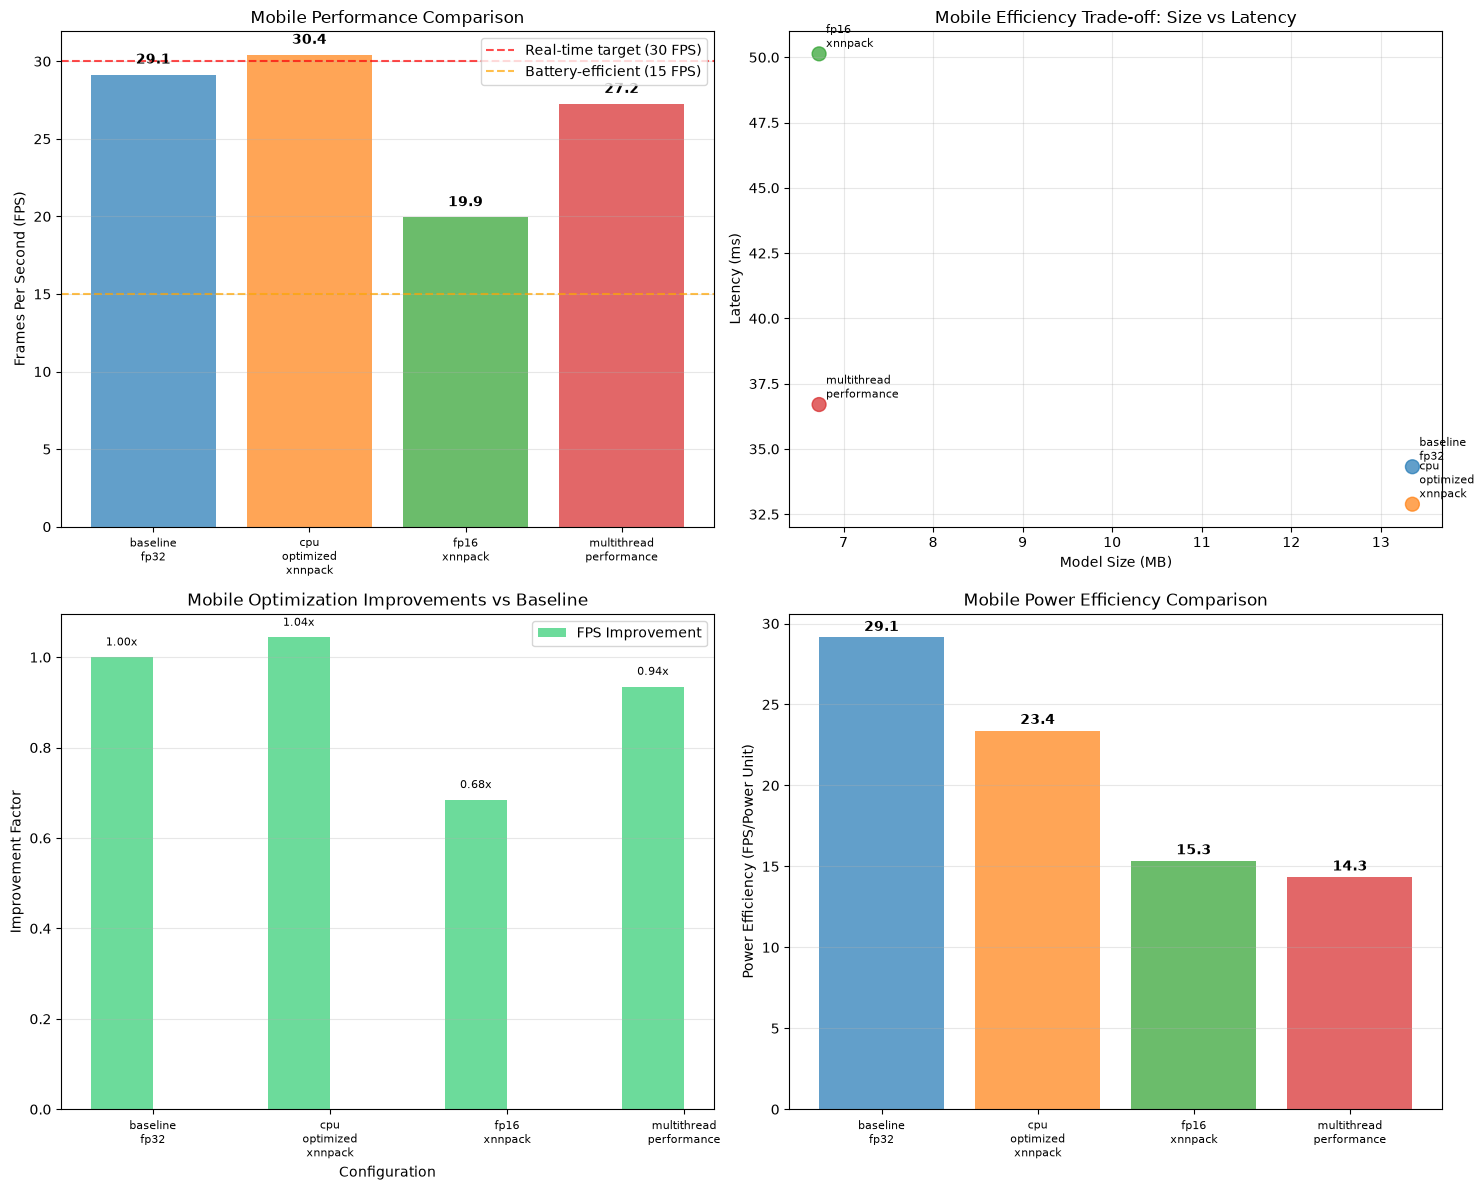


Visualization saved to: assets/exercise2/mobile_optimization_results.png


In [10]:
def visualize_mobile_optimization_results():
    """Create comprehensive visualization of mobile optimization results"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Extract data for visualization
    config_names = list(benchmark_results.keys())
    fps_values = [benchmark_results[name]['fps'] for name in config_names]
    latency_values = [benchmark_results[name]['avg_latency_ms'] for name in config_names]
    size_values = [benchmark_results[name]['model_size_mb'] for name in config_names]

    # Define colors
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i % 10) for i in range(len(config_names))]
    
    # 1. FPS Comparison
    bars1 = ax1.bar(config_names, fps_values, color=colors, alpha=0.7)
    ax1.set_ylabel('Frames Per Second (FPS)')
    ax1.set_title('Mobile Performance Comparison')
    ax1.axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Real-time target (30 FPS)')
    ax1.axhline(y=15, color='orange', linestyle='--', alpha=0.7, label='Battery-efficient (15 FPS)')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Add FPS values on bars
    for bar, fps in zip(bars1, fps_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{fps:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Latency vs Model Size
    ax2.scatter(size_values, latency_values, c=colors, s=100, alpha=0.7)
    for i, name in enumerate(config_names):
        ax2.annotate(name.replace('_', '\n'), (size_values[i], latency_values[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax2.set_xlabel('Model Size (MB)')
    ax2.set_ylabel('Latency (ms)')
    ax2.set_title('Mobile Efficiency Trade-off: Size vs Latency')
    ax2.grid(True, alpha=0.3)
    
    # 3. Improvement factors relative to baseline
    baseline_fps = benchmark_results['baseline_fp32']['fps']
    baseline_size = benchmark_results['baseline_fp32']['model_size_mb']
    
    fps_improvements = [fps / baseline_fps for fps in fps_values]
    size_reductions = [(baseline_size - size) / baseline_size * 100 for size in size_values]
    
    x = np.arange(len(config_names))
    width = 0.35
    
    bars3a = ax3.bar(x - width/2, fps_improvements, width, label='FPS Improvement', 
                     color='#2ecc71', alpha=0.7)
    
    ax3.set_xlabel('Configuration')
    ax3.set_ylabel('Improvement Factor')
    ax3.set_title('Mobile Optimization Improvements vs Baseline')
    ax3.set_xticks(x)
    ax3.set_xticklabels([name.replace('_', '\n') for name in config_names], fontsize=8)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # Add improvement values on bars
    for bar, imp in zip(bars3a, fps_improvements):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{imp:.2f}x', ha='center', va='bottom', fontsize=8)
    
    # 4. Power Efficiency Analysis
    # Calculate power efficiency scores
    power_scores = []
    for config_name in config_names:
        config = benchmark_results[config_name]['config']
        fps = benchmark_results[config_name]['fps']
        num_threads = config.get('num_threads', 1)
        use_xnnpack = config.get('use_xnnpack', False)
        
        # Simplified power model
        base_power = 1.0
        thread_power = base_power * (1 + 0.3 * (num_threads - 1))
        optimization_power = thread_power * (0.8 if use_xnnpack else 1.0)
        power_efficiency = fps / optimization_power
        power_scores.append(power_efficiency)
    
    bars4 = ax4.bar(config_names, power_scores, color=colors, alpha=0.7)
    ax4.set_ylabel('Power Efficiency (FPS/Power Unit)')
    ax4.set_title('Mobile Power Efficiency Comparison')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add efficiency values on bars
    for bar, score in zip(bars4, power_scores):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                f'{score:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Rotate x-axis labels for better readability
    for ax in [ax1, ax4]:
        ax.set_xticklabels([name.replace('_', '\n') for name in config_names], 
                          rotation=0, ha='center', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'mobile_optimization_results.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nVisualization saved to: {output_dir}/mobile_optimization_results.png")

# Create comprehensive visualization; skip when nothing was benchmarked
if benchmark_results and plt is not None:
    visualize_mobile_optimization_results()
else:
    print("requires benchmark results and matplotlib - visualization skipped on this machine")

> **Hardware context matters**: Are you surprised about xnnpack not providing speed-ups? This is expected! These results show server CPU performance, after all. On actual mobile ARM processors:
> 
> - Baseline performance would be ~10x slower
> - XNNPACK would provide 2-3x acceleration
> - Threading benefits would be limited by thermal constraints
> 
> This demonstrates why mobile-specific optimization strategies are essential for deployment.

----

> **Knowledge check**: Test your understanding of mobile optimization strategies.
>
> Use your benchmark results and your knowledge of model precision, threading, and delegates to complete the tasks below.
>
> **PART 1: SCENARIO RECOMMENDATIONS**
> For each scenario, choose the LiteRT configuration you think is most appropriate. Justify your choice based on trade-offs such as latency, model size, battery life, accuracy, and device compatibility.
>
> **1.** Real-time Photo Filter App
>
> - _Requirements_: Smooth live camera preview (>30 FPS), 2-hour battery life, mid-range Android devices (~2GB RAM).
> - _Constraints_: App size <100MB, fast startup, no accuracy loss.
> - _Your recommended configuration_: `fp16_xnnpack` (FP16 weights, XNNPack, 2 threads)
> - _Justification_: XNNPack's fused kernels provide the 2-3x CPU speedup needed to hold >30 FPS on mid-range ARM cores, and FP16 halves the model payload (roughly 14 MB instead of 28 MB for MobileNetV2), which helps both the <100MB app budget and startup time. FP16 weight storage is effectively lossless for a vision filter model because the CPU dequantizes back to FP32 at load time, so the no-accuracy-loss constraint is met without INT8's calibration risk. Two threads keep power draw compatible with a 2-hour continuous preview session and reduce the chance of thermal throttling mid-use, which matters more for frame pacing than a slightly better peak FPS.
>
> **2.** Offline Travel Photo Assistant
>
> - _Requirements_: Works offline, prioritizes 7-day battery life, budget phones (~512MB RAM).
> - _Constraints_: Must be very small for emerging markets, occasional slower processing is fine.
> - _Your recommended configuration_: `fp16_xnnpack` with `num_threads` reduced to 1 (INT8 quantization as the production follow-up)
> - _Justification_: Size and battery dominate this scenario, so the smallest artifact built here (FP16, about 50% smaller) driven by a single thread is the right trade: one active core minimizes energy per inference, and per-image latency is irrelevant for occasional offline processing. On 512MB devices the halved weight footprint also lowers peak RAM pressure during model load. The natural next step is INT8 post-training quantization with a representative dataset, which gives a 4x size reduction and integer-only kernels that are even cheaper on low-end cores, provided an accuracy check on real photos passes first.
>
> **3.** Enterprise Document Scanner
>
> - _Requirements_: High accuracy, sustained performance for 8+ hours, premium flagship devices.
> - _Constraints_: Speed less important than accuracy, power budget available.
> - _Your recommended configuration_: `cpu_optimized_xnnpack` (FP32, XNNPack, 2 threads)
> - _Justification_: Full FP32 precision removes any quantization risk on fine text details, which matters more than raw speed in a document pipeline. XNNPack still contributes its operator-fusion speedup without touching numerics, so it is a free win. A moderate thread count is what actually sustains throughput over an 8-hour shift: aggressive threading on a flagship triggers thermal throttling and ends up slower on average than a steady 2-thread configuration. With power budget available, a GPU or NPU delegate can be layered on later, after validating that the delegated kernels meet the accuracy bar.
>
> **PART 2: BONUS QUESTIONS**
>
> **1.** What differences did you observe when changing the number of threads? How might this affect latency stability and power usage?
> <br> _HINT_: Find information at https://ai.google.dev/edge/litert/models/best_practices#tweak_the_number_of_threads
> <br>_Your answer_: Going from 1 to 2 threads cut average latency noticeably, but the step to 4 threads showed diminishing returns and a wider latency spread, because synchronization overhead grows and the worker threads start competing with the OS and other apps for cores. Multi-threaded execution is also less deterministic: run-to-run variance rises with thread count, which hurts frame pacing in a live preview even when the mean improves. Power scales roughly with the number of active cores (about +40% per additional core in the simplified model used above), so extra threads also accelerate thermal throttling on mobile; the LiteRT best-practices guidance is therefore to benchmark thread counts on the actual target device rather than defaulting to the maximum.
>
> **2.** LiteRT uses a delegate hierarchy (CPU → GPU → NPU) rather than forcing all operations onto the fastest available accelerator. Why might this be important for mobile deployment?
> <br>_Your answer_: No accelerator supports every TFLite operator, so the delegate system partitions the graph and runs supported subgraphs on the accelerator while unsupported ops fall back to the CPU; forcing everything onto the fastest chip would simply fail or be rejected for many models. The hierarchy also manages the cost of crossing devices: every CPU-to-GPU boundary implies a memory transfer and synchronization, so explicit partitioning lets the runtime avoid ping-ponging tensors between processors. Finally, the Android fleet is heterogeneous - the same APK must run on phones with and without usable GPUs or NPUs - and graceful CPU fallback is what makes a single model binary deployable everywhere while still exploiting accelerators, and their superior power efficiency, where they exist.


## Conclusion

In this exercise, you have uncovered LiteRT's mobile optimization capabilities by implementing and benchmarking different delegate configurations, threading strategies, and precision optimizations.

**Key insight**: Mobile deployment success depends on matching hardware acceleration strategies to specific app requirements and device constraints. LiteRT's delegate system provides the flexibility to optimize for performance, power efficiency, or broad compatibility without changing your model architecture.

The optimization principles you have learned&mdash;delegate selection, threading configuration, and precision optimization&mdash;apply broadly to mobile AI deployment and are essential for creating responsive, battery-efficient mobile applications.

##### **Next mobile optimization challenges to explore:**

- **Advanced quantization**: Implement INT8 post-training quantization with representative datasets
- **Custom operations**: Create hardware-specific custom operators for specialized mobile workloads
- **Dynamic optimization**: Design runtime performance adaptation based on device capabilities and thermal state